# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [2]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /Users/franciscolozano/Git/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Cloudbench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Cloudbench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v13,115,0.411207,0.278261,0.012174,0.557229,0.057806,0.255519,0.344734,1
1,Cloudbench,v12,115,0.419258,0.269565,0.012522,0.546148,0.064458,0.202678,0.344411,2
2,Cloudbench,v10,115,0.422418,0.208696,0.009043,0.531803,0.047818,0.201376,0.315557,3
3,Cloudbench,v11,115,0.338866,0.278261,0.012870,0.498933,0.061526,0.201063,0.308564,4
4,Cloudbench,baseline,115,0.299384,0.121739,0.005565,0.490666,0.025862,0.112612,0.210561,5


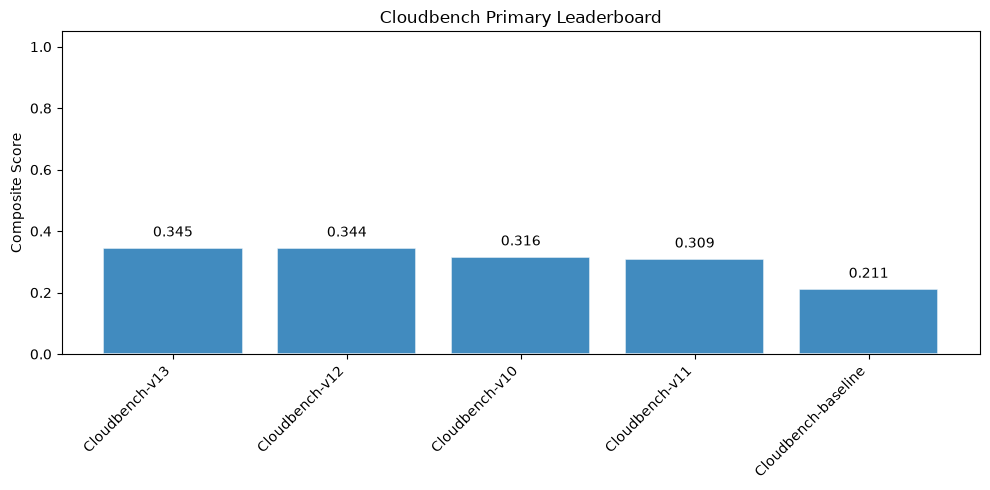

In [3]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Cloudbench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v13,115,0.411207,0.278261,0.012174,0.557229,0.057806,0.255519,0.314996,1
1,Cloudbench,v12,115,0.419258,0.269565,0.012522,0.546148,0.064458,0.202678,0.297167,2
2,Cloudbench,v10,115,0.422418,0.208696,0.009043,0.531803,0.047818,0.201376,0.277497,3
3,Cloudbench,v11,115,0.338866,0.278261,0.012870,0.498933,0.061526,0.201063,0.272730,4
4,Cloudbench,baseline,115,0.299384,0.121739,0.005565,0.490666,0.025862,0.112612,0.177912,5


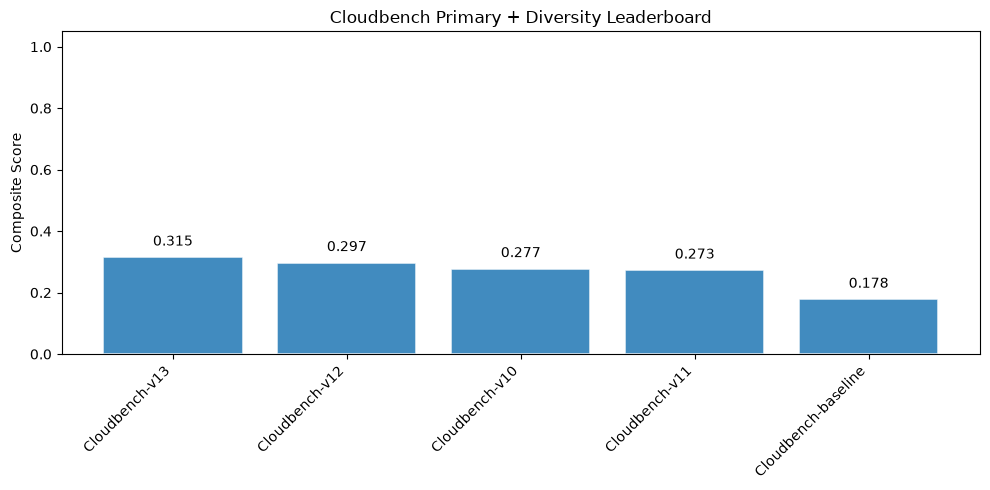

In [4]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Cloudbench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v13,115,0.411207,0.278261,0.012174,0.557229,0.057806,0.255519,0.344734,1
1,Cloudbench,v12,115,0.419258,0.269565,0.012522,0.546148,0.064458,0.202678,0.344411,2
2,Cloudbench,ablation_cap_only,115,0.412931,0.234783,0.010435,0.535074,0.049345,0.218440,0.323857,3
3,Cloudbench,v10,115,0.422418,0.208696,0.009043,0.531803,0.047818,0.201376,0.315557,4
4,Cloudbench,v11,115,0.338866,0.278261,0.012870,0.498933,0.061526,0.201063,0.308564,5
5,Cloudbench,ablation_vec_only,115,0.324439,0.217391,0.010435,0.489526,0.041006,0.137431,0.270915,6
6,Cloudbench,ablation_img_only,115,0.274034,0.191304,0.008696,0.483532,0.042184,0.130437,0.232669,7
7,Cloudbench,baseline,115,0.299384,0.121739,0.005565,0.490666,0.025862,0.112612,0.210561,8


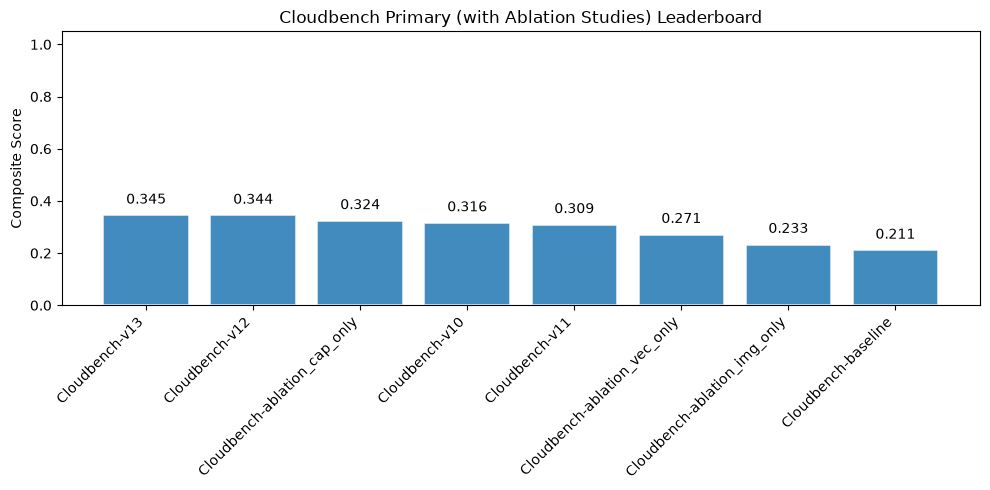

In [5]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)